<a href="https://www.kaggle.com/code/sonawanelalitsunil/predicting-blood-donor-availability-ml-51-55?scriptVersionId=256995530" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/blood-donor-dataset/blood_donor_dataset.csv


## Title: 
🔴 Predicting Blood Donor Availability

## Description:
This project focuses on building a data-driven model to predict the availability of blood donors, helping healthcare organizations and blood banks maintain a steady blood supply. By analyzing demographic, behavioral, and health-related factors—such as age, donation history, lifestyle habits, and medical conditions—the model identifies patterns that influence donor reliability and future donation likelihood. The insights can assist in scheduling donation drives, reducing shortages, and improving resource planning.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/blood-donor-dataset/blood_donor_dataset.csv")

In [3]:
df.head()

,donor_id,name,email,password,contact_number,city,blood_group,availability,months_since_first_donation,number_of_donation,pints_donated,created_at
0,1b8b4c828a,Norma Fisher,ysullivan@yahoo.com,P5hX6Syg*A,+61 461706749,Hobart,A+,No,65,31,62,2017-03-17
1,a6a3f7fe55,Eugene Bowman,hramos@brown-sellers.com,b6Wq6Cqz@5,+61 450709944,Darwin,AB-,Yes,64,8,16,2016-11-11
2,cee6478144,Sheri Bolton DDS,jasmine85@hotmail.com,$9RB51m#s7,+61 428756361,Melbourne,AB+,Yes,39,6,6,2022-02-25
3,5986bc55f9,Kelly Boyd,pattylawrence@riley-hayes.com,@5Tdg(4kCm,+61 454318320,Darwin,A-,No,55,20,20,2025-04-04
4,93246afe6c,Taylor Guzman,martinezjacob@wilson.com,x!)9Ag@J*7,+61 484158472,Darwin,O-,No,7,35,35,2022-11-30


In [4]:
df.tail()

,donor_id,name,email,password,contact_number,city,blood_group,availability,months_since_first_donation,number_of_donation,pints_donated,created_at
9995,700aeefbf1,Bradley Pham,jessica49@turner.com,^@d9SMqSa1,+61 443906132,Hobart,A+,Yes,66,42,42,2019-02-11
9996,487b342992,Richard Harris,megan51@gmail.com,D1OAZg5i)g,+61 443105290,Hobart,O-,No,65,14,28,2025-02-18
9997,ddf4485d67,Autumn Kim,curtisdonald@wilson.info,3wU2fua(#7,+61 472390553,Hobart,B+,No,57,16,32,2019-04-29
9998,4256813ba5,Janice Murphy,jenningscristian@hotmail.com,&8zDeXl)b(,+61 492945719,Perth,AB-,Yes,79,23,46,2022-08-23
9999,5452d8afd3,Edward Graham,oyates@yahoo.com,ud(J5UjHh9,+61 475905869,Canberra,O-,No,103,8,8,2016-09-28


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   donor_id                     10000 non-null  object
 1   name                         10000 non-null  object
 2   email                        10000 non-null  object
 3   password                     10000 non-null  object
 4   contact_number               10000 non-null  object
 5   city                         10000 non-null  object
 6   blood_group                  10000 non-null  object
 7   availability                 10000 non-null  object
 8   months_since_first_donation  10000 non-null  int64 
 9   number_of_donation           10000 non-null  int64 
 10  pints_donated                10000 non-null  int64 
 11  created_at                   10000 non-null  object
dtypes: int64(3), object(9)
memory usage: 937.6+ KB


In [6]:
df.describe()

,months_since_first_donation,number_of_donation,pints_donated
count,10000.000000,10000.000000,10000.000000
mean,59.953100,25.128200,37.614000
std,34.911379,14.654195,26.334072
min,0.000000,0.000000,0.000000
25%,30.000000,12.000000,16.000000
50%,60.000000,26.000000,34.000000
75%,90.000000,38.000000,50.000000
max,120.000000,50.000000,100.000000


In [7]:
df.isnull().sum()

donor_id                       0
name                           0
email                          0
password                       0
contact_number                 0
city                           0
blood_group                    0
availability                   0
months_since_first_donation    0
number_of_donation             0
pints_donated                  0
created_at                     0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

donor_id                       object
name                           object
email                          object
password                       object
contact_number                 object
city                           object
blood_group                    object
availability                   object
months_since_first_donation     int64
number_of_donation              int64
pints_donated                   int64
created_at                     object
dtype: object

In [10]:
df.shape

(10000, 12)

In [11]:
df.columns

Index(['donor_id', 'name', 'email', 'password', 'contact_number', 'city',
       'blood_group', 'availability', 'months_since_first_donation',
       'number_of_donation', 'pints_donated', 'created_at'],
      dtype='object')

## Data visualizations

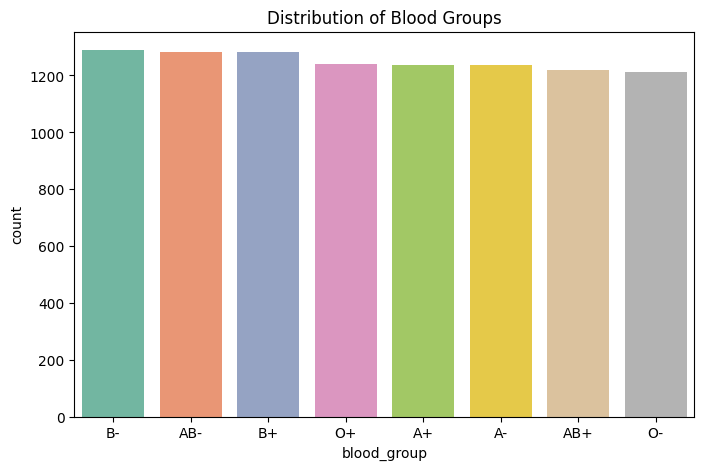

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(x="blood_group", data=df, order=df['blood_group'].value_counts().index, palette="Set2")
plt.title("Distribution of Blood Groups")
plt.show()


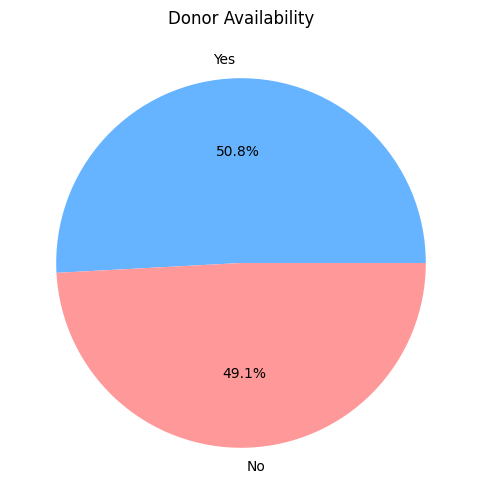

In [13]:
plt.figure(figsize=(6,6))
df['availability'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
plt.title("Donor Availability")
plt.ylabel("")
plt.show()


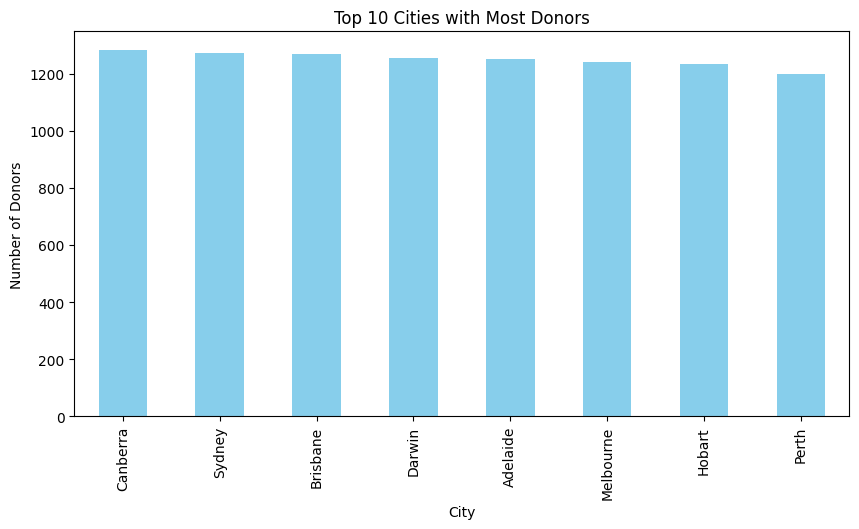

In [14]:
plt.figure(figsize=(10,5))
df['city'].value_counts().head(10).plot(kind='bar', color="skyblue")
plt.title("Top 10 Cities with Most Donors")
plt.xlabel("City")
plt.ylabel("Number of Donors")
plt.show()


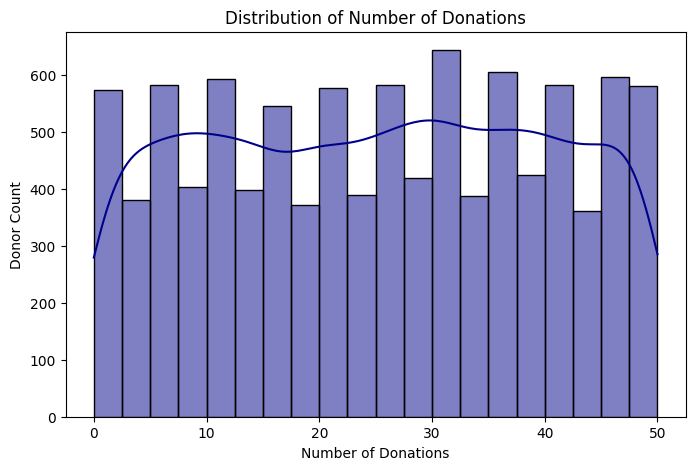

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['number_of_donation'], bins=20, kde=True, color="darkblue")
plt.title("Distribution of Number of Donations")
plt.xlabel("Number of Donations")
plt.ylabel("Donor Count")
plt.show()


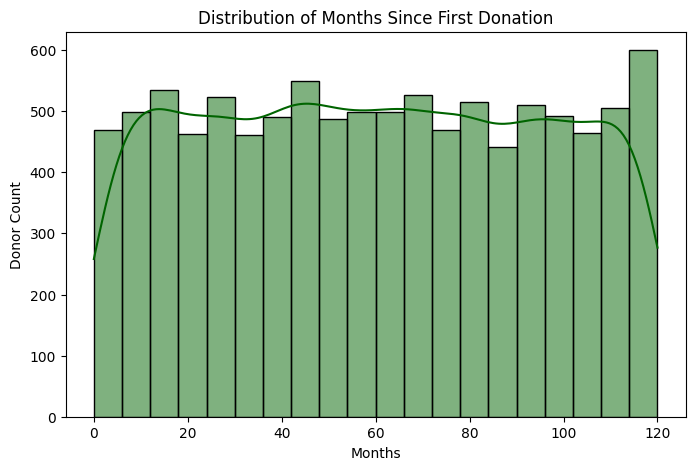

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['months_since_first_donation'], bins=20, kde=True, color="darkgreen")
plt.title("Distribution of Months Since First Donation")
plt.xlabel("Months")
plt.ylabel("Donor Count")
plt.show()


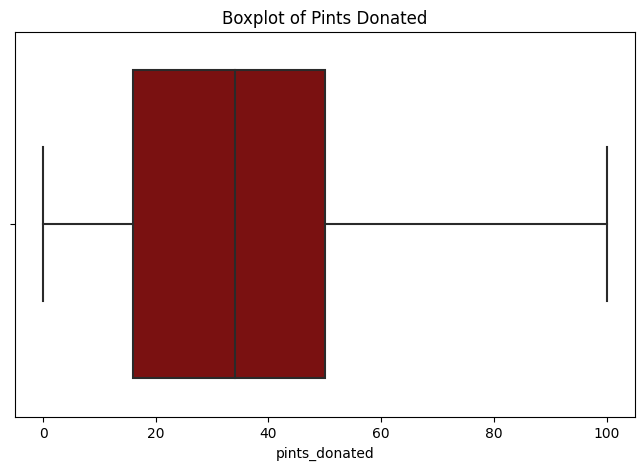

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['pints_donated'], color="darkred")
plt.title("Boxplot of Pints Donated")
plt.show()


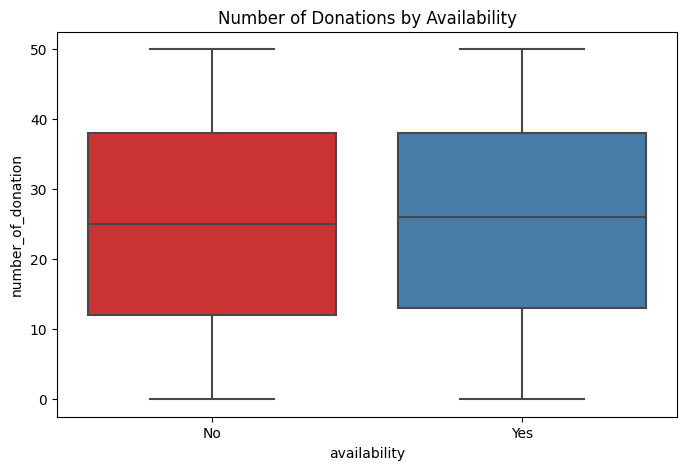

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x="availability", y="number_of_donation", data=df, palette="Set1")
plt.title("Number of Donations by Availability")
plt.show()


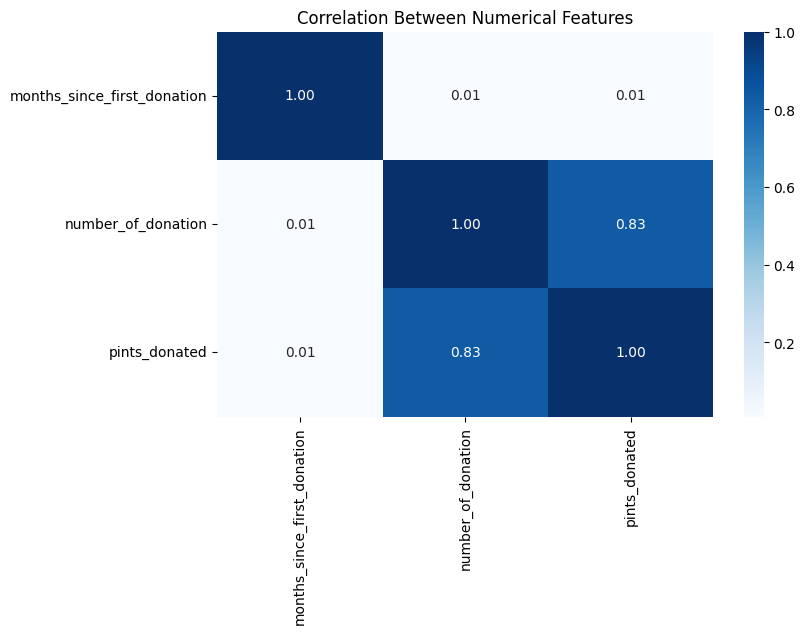

In [19]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['months_since_first_donation','number_of_donation','pints_donated']].corr(),
            annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Between Numerical Features")
plt.show()


## Predictive modeling|

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [21]:
df = df.drop(['donor_id','name','email','password','contact_number','created_at'], axis=1)

# Encode categorical columns
cat_cols = ['city','blood_group','availability']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Features & Target
X = df.drop('availability', axis=1)
y = df['availability']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
# ===============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = {}


In [24]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    results[name] = round(acc, 2)

In [25]:
results_df = pd.DataFrame(list(results.items()), columns=["Algorithm", "Accuracy (%)"])
print(results_df)

             Algorithm  Accuracy (%)
0  Logistic Regression         51.55
1        Decision Tree         49.60
2        Random Forest         48.50
3    Gradient Boosting         48.65
4                  KNN         48.55
5                  SVM         50.10
6              XGBoost         47.60


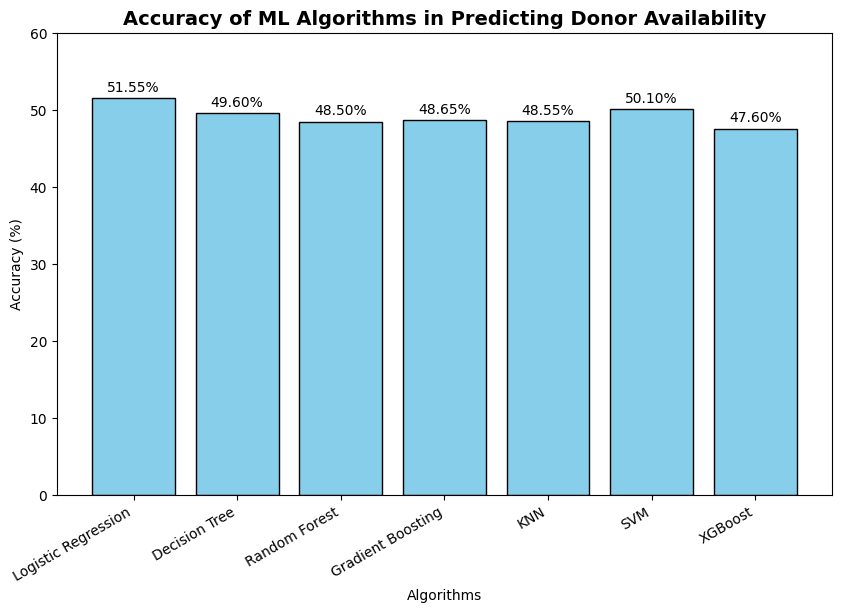

In [26]:
results_df = pd.DataFrame({
    "Algorithm": ["Logistic Regression","Decision Tree","Random Forest","Gradient Boosting","KNN","SVM","XGBoost"],
    "Accuracy (%)": [51.55,49.60,48.50,48.65,48.55,50.10,47.60]
})

# Plot
plt.figure(figsize=(10,6))
bars = plt.bar(results_df["Algorithm"], results_df["Accuracy (%)"], color="skyblue", edgecolor="black")

# Add accuracy values on bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f"{bar.get_height():.2f}%", ha='center', va='bottom', fontsize=10)

plt.title("Accuracy of ML Algorithms in Predicting Donor Availability", fontsize=14, weight='bold')
plt.xlabel("Algorithms")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 60)  # since your accuracies are low
plt.show()

## Thank you ...pls upvote!!!